# Método das Diferenças Finitas (MDF)

O **MDF** resolve **equações diferenciais parciais (EDPs)** substituindo as
**derivadas** por **aproximações discretas** calculadas sobre uma **malha** de pontos.

## Discretização

A segunda derivada é aproximada por diferenças centradas. Em uma malha 2D de
espaçamento $h$, o **laplaciano** $\nabla^2 \phi = \phi_{xx} + \phi_{yy}$ vira:

$$
\nabla^2 \phi \approx
\frac{\phi_{i+1,j} + \phi_{i-1,j} + \phi_{i,j+1} + \phi_{i,j-1} - 4\,\phi_{i,j}}{h^2}
$$

Essa é a famosa **estrela de 5 pontos** (*five-point stencil*).

## Equação de Laplace ($\nabla^2 T = 0$)

Modela um campo em **regime permanente sem fontes** (ex.: temperatura numa placa).
Igualando o laplaciano a zero, cada ponto interno é a **média dos 4 vizinhos**:

$$
T_{i,j} = \tfrac{1}{4}\left(T_{i+1,j} + T_{i-1,j} + T_{i,j+1} + T_{i,j-1}\right)
$$

## Equação de Poisson ($\nabla^2 \phi = -\rho/\varepsilon_0$)

Inclui um **termo de fonte** $\rho$ (ex.: densidade de carga elétrica):

$$
\phi_{i,j} = \tfrac{1}{4}\left(\phi_{i+1,j} + \phi_{i-1,j} + \phi_{i,j+1} + \phi_{i,j-1}
+ \frac{h^2 \rho_{i,j}}{\varepsilon_0}\right)
$$

## Solução iterativa (Gauss-Seidel)

O sistema linear resultante é resolvido **iterativamente**: varre-se a malha
atualizando cada ponto, repetindo até que a maior variação `delta` entre duas
varreduras fique abaixo da tolerância `erro`. Como cada ponto usa os valores
**já atualizados** dos vizinhos na mesma varredura, trata-se do método de
**Gauss-Seidel**, que converge mais rápido que Jacobi.

> **Nos scripts:** Laplace para a distribuição de temperatura numa placa com
> bordas a temperaturas fixas; Poisson para o potencial elétrico de duas cargas
> puntiformes (uma positiva e uma negativa).

In [1]:
def gauss_seidel_laplace(Temp, N, erro, max_iter):
    iteracoes = 0
    delta = 1.0

    while delta > erro and iteracoes < max_iter:
        delta = 0.0
        iteracoes += 1

        for i in range(1, N):
            for j in range(1, N):
                T_old = Temp[i, j]

                Temp[i, j] = 0.25 * (
                    Temp[i+1, j] + Temp[i-1, j] +
                    Temp[i, j+1] + Temp[i, j-1]
                )

                diff = abs(Temp[i, j] - T_old)
                if diff > delta:
                    delta = diff

    return Temp, iteracoes

def gauss_seidel(phi, rho, h, epsilon0, tol=1e-5, max_iter=10000):
    N = phi.shape[0] - 1
    iteracoes = 0

    for _ in range(max_iter):
        delta = 0.0

        for i in range(1, N):
            for j in range(1, N):
                phi_old = phi[i, j]

                phi[i, j] = 0.25 * (
                    phi[i+1, j] + phi[i-1, j] +
                    phi[i, j+1] + phi[i, j-1] +
                    h**2 * rho[i, j] / epsilon0
                )

                diff = abs(phi[i, j] - phi_old)
                if diff > delta:
                    delta = diff

        iteracoes += 1

        if delta < tol:
            print(f"Convergiu em {iteracoes} iterações.")
            return phi

    print("Não convergiu dentro do limite.")
    return phi

**MDF — Equação de Laplace (Distribuição de Temperatura)**

Tempo de execução: 86.0119 segundos


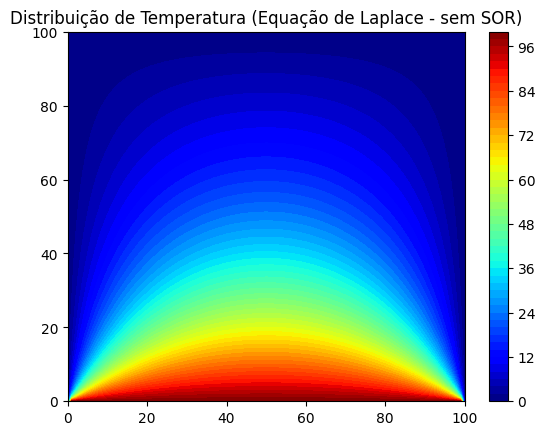

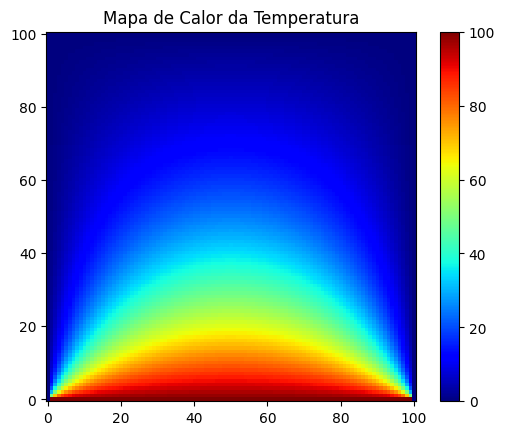

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

inicio = time.time()

# Tamanho do Grid
N = 100

# Condições de contorno
T_sup = 100
T_dir = 0
T_est = 0
T_inf = 0
erro  = 1e-6

# Inicializa o array de temperatura
Temp = np.zeros([N+1, N+1], float)
Temp[0, :]  = T_sup  # Borda superior
Temp[-1, :] = T_inf  # Borda inferior
Temp[:, 0]  = T_est  # Borda esquerda
Temp[:, -1] = T_dir  # Borda direita

# Iteração de Gauss-Seidel
delta = 1.0
while delta > erro:
    delta = 0.0
    for i in range(1, N):
        for j in range(1, N):
            T_old = Temp[i, j]
            Temp[i, j] = 0.25 * (Temp[i+1, j] + Temp[i-1, j] + Temp[i, j+1] + Temp[i, j-1])
            diff = abs(Temp[i, j] - T_old)
            if diff > delta:
                delta = diff

fim = time.time()
print(f"Tempo de execução: {fim - inicio:.4f} segundos")

# Visualização da solução
X, Y = np.meshgrid(np.arange(0, N+1), np.arange(0, N+1))
plt.contourf(X, Y, Temp, 50, cmap='jet')
plt.colorbar()
plt.title("Distribuição de Temperatura (Equação de Laplace - sem SOR)")

plt.figure()
plt.imshow(Temp, origin='lower', cmap='jet')
plt.colorbar()
plt.title("Mapa de Calor da Temperatura")
plt.show()


**MDF — Equação de Laplace usando a função `gauss_seidel_laplace`**

Mesma solução, agora resolvida pela função auxiliar definida no início do notebook.

Convergiu em 10000 iterações.
Tempo de execução: 64.0557 segundos


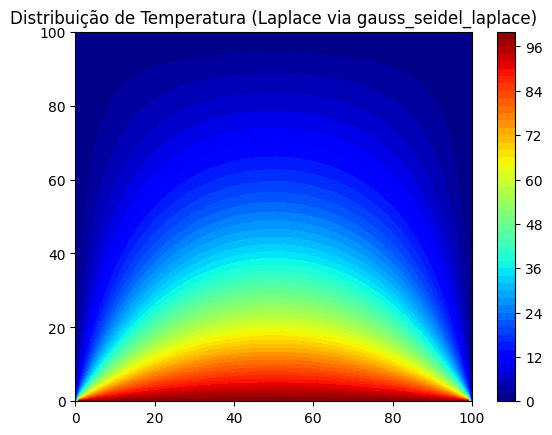

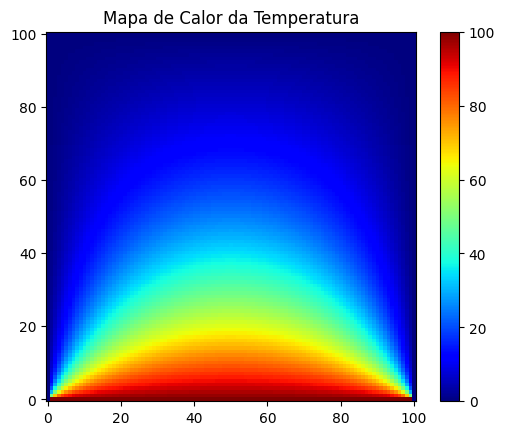

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Tamanho do Grid
N = 100

# Condições de contorno
T_sup = 100
T_dir = 0
T_est = 0
T_inf = 0
erro     = 1e-6
max_iter = 10000

# Inicializa o array de temperatura com as bordas fixas
Temp = np.zeros([N+1, N+1], float)
Temp[0, :]  = T_sup  # Borda superior
Temp[-1, :] = T_inf  # Borda inferior
Temp[:, 0]  = T_est  # Borda esquerda
Temp[:, -1] = T_dir  # Borda direita

# Resolve usando a função gauss_seidel_laplace
inicio = time.time()
Temp, iteracoes = gauss_seidel_laplace(Temp, N, erro, max_iter)
fim = time.time()

print(f"Convergiu em {iteracoes} iterações.")
print(f"Tempo de execução: {fim - inicio:.4f} segundos")

# Visualização da solução
X, Y = np.meshgrid(np.arange(0, N+1), np.arange(0, N+1))
plt.contourf(X, Y, Temp, 50, cmap='jet')
plt.colorbar()
plt.title("Distribuição de Temperatura (Laplace via gauss_seidel_laplace)")

plt.figure()
plt.imshow(Temp, origin='lower', cmap='jet')
plt.colorbar()
plt.title("Mapa de Calor da Temperatura")
plt.show()


**MDF — Equação de Poisson (Potencial Elétrico de Duas Cargas)**

Convergiu em 1509 iterações.


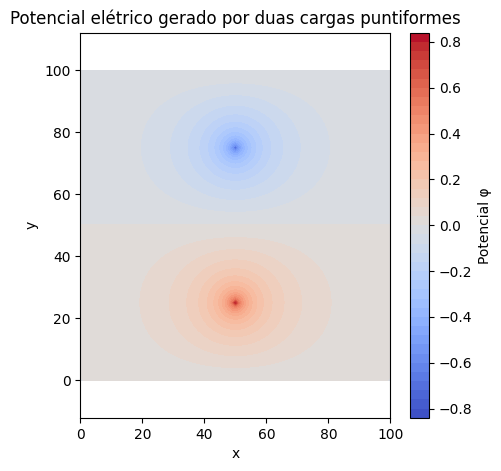

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros físicos e da malha
N       = 100   # Tamanho do grid (N x N)
h       = 1.0   # Espaçamento da malha
q       = 1.0   # Valor da carga (em unidades arbitrárias)
epsilon0 = 1.0  # Permissividade (também arbitrária)
erro    = 1e-5  # Critério de convergência

# Inicializa o potencial e a densidade de carga
phi = np.zeros((N+1, N+1))
rho = np.zeros((N+1, N+1))

# Posições das duas cargas (carga positiva e carga negativa)
i1, j1 = 25, 50  # Carga +q
i2, j2 = 75, 50  # Carga -q

# Define a densidade de carga na malha (discretização da função delta)
rho[i1, j1] =  q / h**2
rho[i2, j2] = -q / h**2

# Método iterativo de Gauss-Seidel
delta    = 1.0
iteracoes = 0

while delta > erro:
    delta = 0.0
    for i in range(1, N):
        for j in range(1, N):
            phi_old = phi[i, j]
            phi[i, j] = 0.25 * (
                phi[i+1, j] + phi[i-1, j] + phi[i, j+1] + phi[i, j-1]
                + h**2 * rho[i, j] / epsilon0
            )
            diff = abs(phi[i, j] - phi_old)
            if diff > delta:
                delta = diff
    iteracoes += 1

print(f"Convergiu em {iteracoes} iterações.")

# Visualização do potencial elétrico
plt.figure(figsize=(5, 5))
plt.contourf(phi, levels=50, cmap='coolwarm')
plt.colorbar(label='Potencial φ')
plt.title("Potencial elétrico gerado por duas cargas puntiformes")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.show()


**MDF — Equação de Poisson usando a função `gauss_seidel`**

Mesma solução, agora resolvida pela função auxiliar definida no início do notebook.

Convergiu em 1509 iterações.


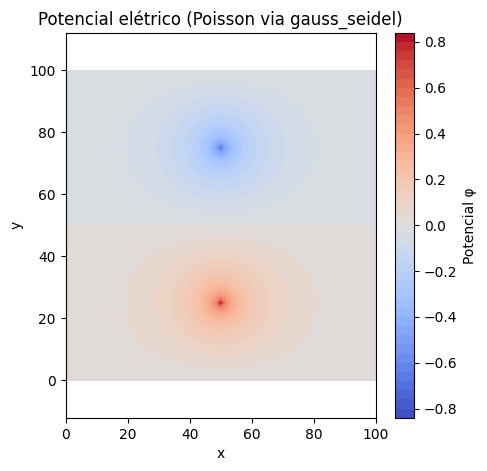

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros físicos e da malha
N        = 100   # Tamanho do grid (N x N)
h        = 1.0   # Espaçamento da malha
q        = 1.0   # Valor da carga (em unidades arbitrárias)
epsilon0 = 1.0   # Permissividade (também arbitrária)
erro     = 1e-5  # Critério de convergência

# Inicializa o potencial e a densidade de carga
phi = np.zeros((N+1, N+1))
rho = np.zeros((N+1, N+1))

# Posições das duas cargas (carga positiva e carga negativa)
i1, j1 = 25, 50  # Carga +q
i2, j2 = 75, 50  # Carga -q
rho[i1, j1] =  q / h**2
rho[i2, j2] = -q / h**2

# Resolve usando a função gauss_seidel
phi = gauss_seidel(phi, rho, h, epsilon0, tol=erro, max_iter=10000)

# Visualização do potencial elétrico
plt.figure(figsize=(5, 5))
plt.contourf(phi, levels=50, cmap='coolwarm')
plt.colorbar(label='Potencial φ')
plt.title("Potencial elétrico (Poisson via gauss_seidel)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.show()
